# SIFT (Scale-Invariant Feature Transform)!

Imagínate que SIFT es como un detective súper obsesivo que puede reconocer a sus amigos incluso si:

- Están muy lejos (escala diferente) 🔍
- Giraron la cabeza (rotación) 🌀
- Se movieron a otro lugar (translación) 📍
- La iluminación cambió completamente 💡

SIFT es básicamente el Sherlock Holmes de los píxeles, pero con esteroides matemáticos.

## ¿Cómo Funciona Este Mago Pixelado?

- Paso 1: "¡Busquemos puntos interesantes!" 🎯
SIFT usa algo llamado "Difference of Gaussians" (DoG) - imagínate que aplica filtros borrosos de diferentes intensidades y luego los resta. Es como tener rayos X para encontrar las esquinas y bordes más "cool" de la imagen.

- Paso 2: "¡Eliminemos a los impostores!" 🕵️
No todos los puntos son dignos. SIFT hace una auditoría brutal y elimina puntos débiles, bordes poco definidos y cualquier cosa que no sea lo suficientemente "extreme".

- Paso 3: "¡Asignemos orientaciones como brújulas!" 🧭
Para cada punto superviviente, SIFT calcula una orientación dominante usando gradientes. Es como ponerle una flecha que apunta hacia "su norte magnético personal".

- Paso 4: "¡Creemos huellas dactilares matemáticas!" 👆
Finalmente, crea descriptores de 128 dimensiones. Son como DNAs únicos para cada punto característico.

# ¿Por Qué SIFT es Tan Genial?

- Invariante a escala: Puede reconocer un objeto si está lejos o cerca
- Invariante a rotación: No importa si la imagen está rotada
- Robusto a iluminación: Funciona con diferentes condiciones de luz
- Distintivo: Cada descriptor es como una huella digital única

# El Lado Oscuro de SIFT 😈

Es patentado (aunque ya expiró la patente en 2020)
Computacionalmente costoso - no es para tiempo real en dispositivos móviles
A veces detecta demasiados puntos (es muy entusiasta)

Dato friki: SIFT fue inventado por David Lowe en 1999, y revolucionó computer vision. ¡Es como el iPhone del reconocimiento de características!
¿Necesitas que ajuste algo del código o quieres explorar algún aspecto específico de SIFT? ¡Este detective pixelado tiene muchos más trucos bajo la manga! 🎩✨



SIFT (Scale-Invariant Feature Transform) - Explicación Técnica
SIFT es un algoritmo fundamental en visión por computadora que detecta y describe características distintivas en imágenes de manera robusta ante cambios de escala, rotación e iluminación.
¿Qué Problema Resuelve SIFT?
El desafío principal en reconocimiento de imágenes es encontrar puntos característicos que sean consistentes bajo diferentes condiciones:

Cambios de tamaño (zoom in/out)
Rotaciones
Cambios de iluminación
Diferentes puntos de vista

Proceso de Funcionamiento
1. Detección de Extremos en el Espacio de Escalas
SIFT construye una pirámide de imágenes aplicando filtros Gaussianos con diferentes valores de σ (sigma). Luego calcula la "Diferencia de Gaussianas" (DoG) entre escalas consecutivas para detectar puntos de interés.
2. Localización Precisa de Puntos Clave
Se refinan las ubicaciones de los candidatos eliminando:

Puntos con bajo contraste
Puntos localizados en bordes (que son menos distintivos)

3. Asignación de Orientación
Para cada punto clave se calcula la orientación dominante usando:

Gradientes de la imagen en la vecindad del punto
Histograma de orientaciones ponderado por magnitud

4. Generación del Descriptor
Se crea un descriptor de 128 dimensiones que:

Describe la región alrededor del punto clave
Es invariante a rotación y escala
Es robusto ante cambios de iluminación


Ventajas de SIFT

Robustez: Funciona bajo diferentes condiciones de vista
Distintividad: Los descriptores son únicos y diferenciables
Estabilidad: Los mismos puntos se detectan consistentemente
Versatilidad: Útil para múltiples aplicaciones (matching, reconocimiento, tracking)

Limitaciones

Costo computacional: Relativamente lento para aplicaciones en tiempo real
Densidad de características: Puede generar muchos puntos en imágenes texturadas
Patentes: Históricamente fue algoritmo patentado (expirado en 2020)

Aplicaciones Principales

Reconocimiento de objetos
Stitching de imágenes (panoramas)
Tracking de objetos
Calibración de cámaras
Reconstrucción 3D

SIFT sigue siendo uno de los algoritmos más importantes en visión por computadora, especialmente para aplicaciones que requieren robustez ante transformaciones geométricas.

https://www.youtube.com/watch?v=yCVjPZQcMP4

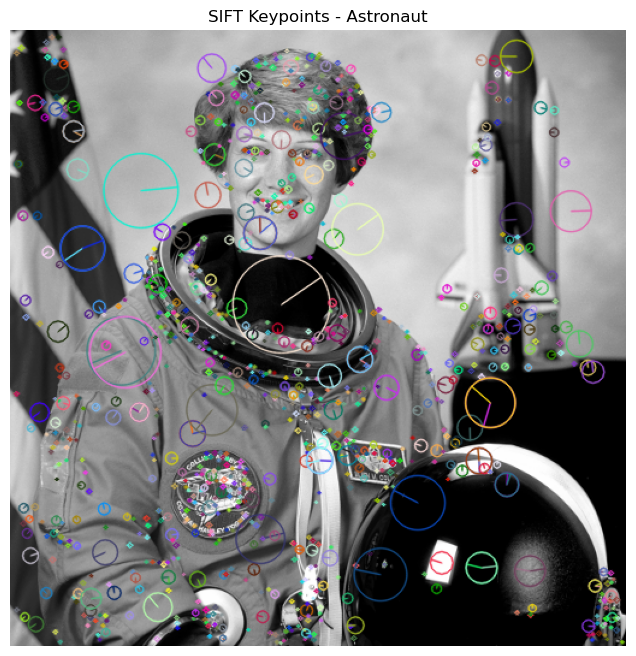

In [13]:
import cv2
from skimage import data

import matplotlib.pyplot as plt

# Cargar la imagen de ejemplo del astronauta
astronaut = data.astronaut()
astronaut_gray = cv2.cvtColor(astronaut, cv2.COLOR_RGB2GRAY)

# Crear el objeto SIFT
sift = cv2.SIFT_create()

# Detectar y calcular los keypoints y descriptores
keypoints, descriptors = sift.detectAndCompute(astronaut_gray, None)

# Dibujar los keypoints en la imagen
img_sift = cv2.drawKeypoints(astronaut_gray, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Mostrar la imagen con los keypoints
plt.figure(figsize=(8, 8))
plt.imshow(img_sift)
plt.axis('off')
plt.title('SIFT Keypoints - Astronaut')
plt.show()

# Homografía
Este filtro es uno de los utilizados para hacer una comparación (relativamente simple) entre dos objetos iguales, para detectar un cambio de posición, iluminación o escala.


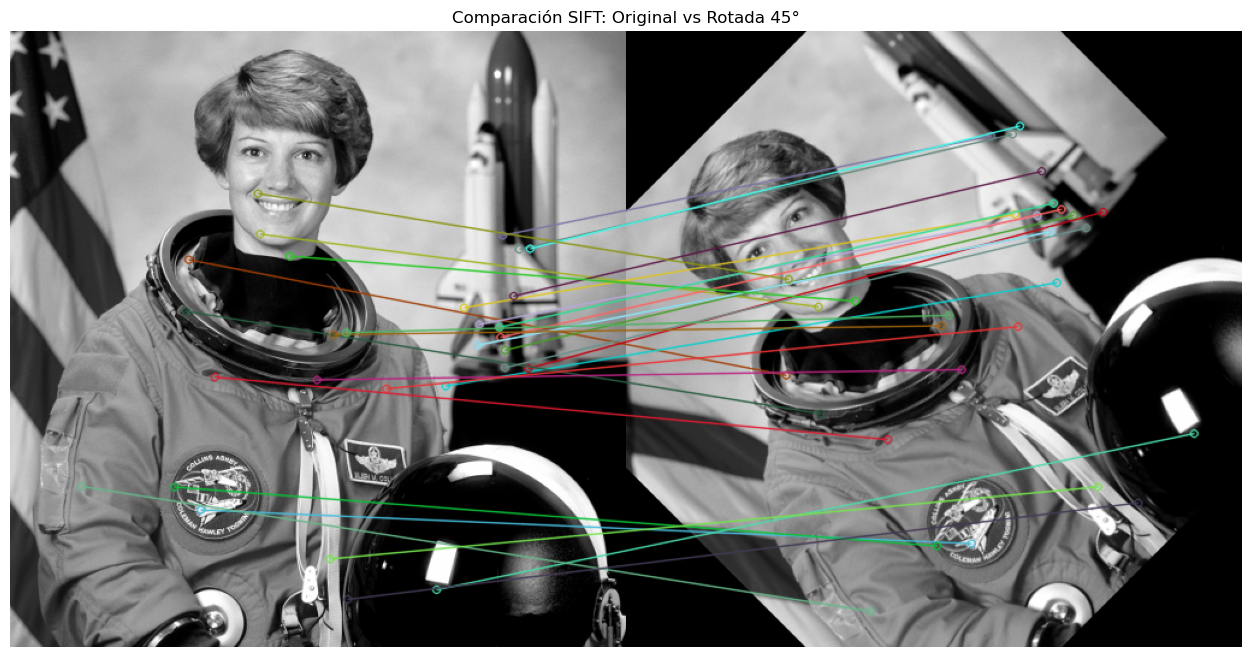

In [16]:
# Rotar la imagen 45 grados
(h, w) = astronaut_gray.shape
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
astronaut_rotated = cv2.warpAffine(astronaut_gray, M, (w, h))

# Detectar keypoints y descriptores en la imagen rotada
keypoints_rot, descriptors_rot = sift.detectAndCompute(astronaut_rotated, None)

# Matcher por fuerza bruta con norma L2
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors, descriptors_rot)
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar los mejores 30 matches
img_matches = cv2.drawMatches(
    astronaut_gray, keypoints,
    astronaut_rotated, keypoints_rot,
    matches[:30], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(img_matches)
plt.axis('off')
plt.title('Comparación SIFT: Original vs Rotada 45°')
plt.show()

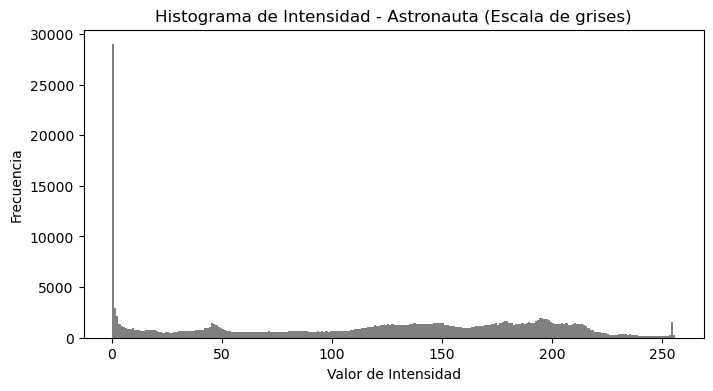

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(astronaut_gray.ravel(), bins=256, range=(0, 256), color='gray')
plt.title('Histograma de Intensidad - Astronauta (Escala de grises)')
plt.xlabel('Valor de Intensidad')
plt.ylabel('Frecuencia')
plt.show()

Este filtro se 

Aquí tenemos otro ejemplo en el que usamos SIFT para comparar dos imágenes similares (se pueden ver algunos errores en la comparación en la base de la estatua )

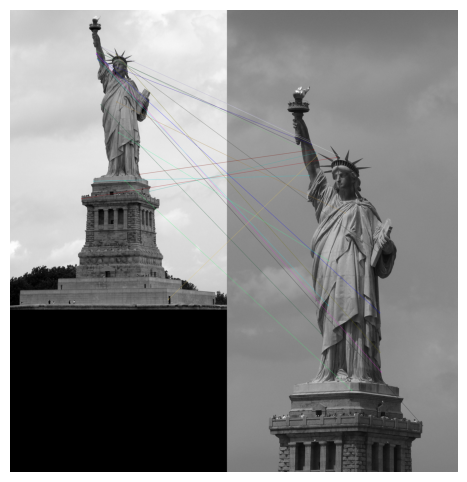

In [35]:
import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/a/a1/Statue_of_Liberty_7.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/1/14/Statue_of_Liberty_25.jpg"
]

def load_image_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}  # cabecera para evitar bloqueo
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        raise ValueError(f"Error al descargar {url}, status {resp.status_code}")
    img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo decodificar la imagen desde {url}")
    return img

# Cargar imágenes con chequeo
img1 = load_image_from_url(urls[0])
img2 = load_image_from_url(urls[1])

# --- SIFT ---
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

# Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12,6))
plt.imshow(img_matches, cmap="gray")
plt.axis("off")
plt.show()


Aplicar Filtros como Sobel o Canny puede ayudar a detectar mejor puntos de interés comunes entre ambas imágenes.

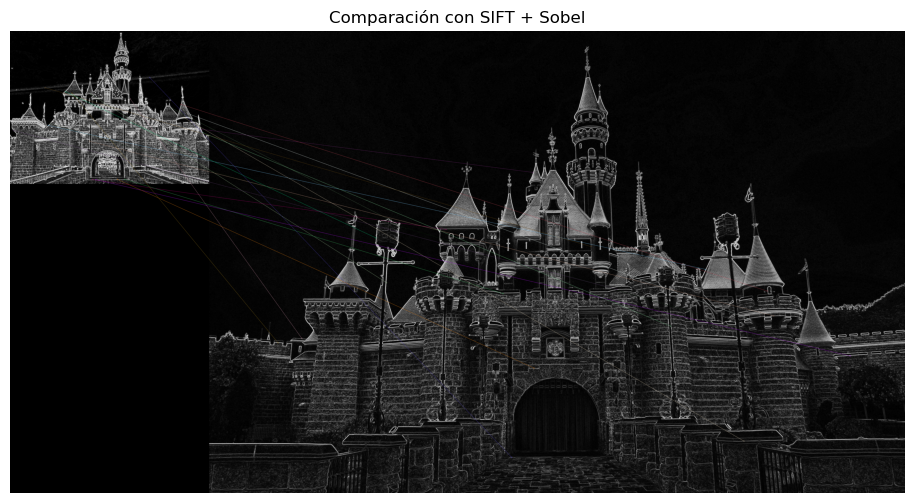

In [34]:
import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

urls = [
    "https://static.wikia.nocookie.net/disney/images/8/89/Sleeping_Beauty_Castle_DLR.jpg",
    "https://static.wikia.nocookie.net/disney/images/4/48/Sleeping_Beauty_Castle_of_Hong_Kong_Disneyland.jpg"
]

def load_image_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}  # cabecera para evitar bloqueo
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        raise ValueError(f"Error al descargar {url}, status {resp.status_code}")
    img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo decodificar la imagen desde {url}")
    return img

def apply_sobel(img):
    """Aplicar filtro Sobel en X e Y y combinar"""
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.convertScaleAbs(sobel)  # convertir a 8 bits
    return sobel

# Cargar imágenes
img1 = load_image_from_url(urls[0])
img2 = load_image_from_url(urls[1])

# Aplicar Sobel
sobel1 = apply_sobel(img1)
sobel2 = apply_sobel(img2)

# --- SIFT ---
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(sobel1, None)
kp2, des2 = sift.detectAndCompute(sobel2, None)

# Matcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Dibujar coincidencias
img_matches = cv2.drawMatches(sobel1, kp1, sobel2, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12,6))
plt.imshow(img_matches, cmap="gray")
plt.title("Comparación con SIFT + Sobel")
plt.axis("off")
plt.show()


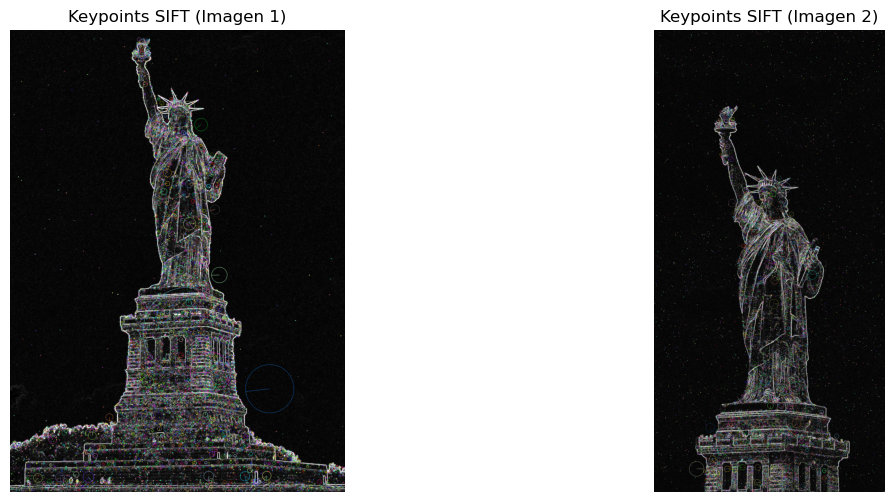

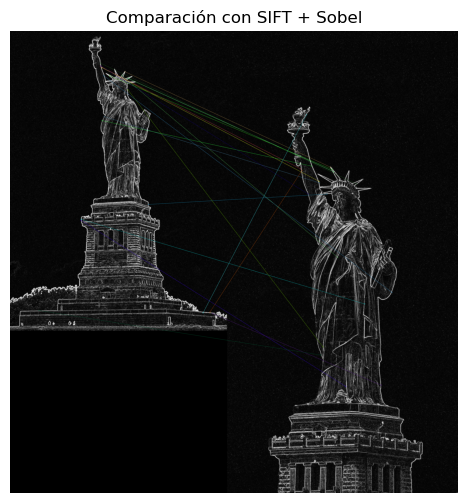

In [32]:
import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/a/a1/Statue_of_Liberty_7.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/1/14/Statue_of_Liberty_25.jpg"
]

def load_image_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        raise ValueError(f"Error al descargar {url}, status {resp.status_code}")
    img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo decodificar la imagen desde {url}")
    return img

def apply_sobel(img):
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    sobel = cv2.convertScaleAbs(sobel)
    return sobel

# Cargar imágenes
img1 = load_image_from_url(urls[0])
img2 = load_image_from_url(urls[1])

# Aplicar Sobel
sobel1 = apply_sobel(img1)
sobel2 = apply_sobel(img2)

# --- SIFT ---
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(sobel1, None)
kp2, des2 = sift.detectAndCompute(sobel2, None)

# Dibujar keypoints en cada imagen
img1_kp = cv2.drawKeypoints(sobel1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(sobel2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.imshow(img1_kp, cmap="gray")
plt.title("Keypoints SIFT (Imagen 1)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2_kp, cmap="gray")
plt.title("Keypoints SIFT (Imagen 2)")
plt.axis("off")
plt.show()

# --- Matching ---
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

img_matches = cv2.drawMatches(sobel1, kp1, sobel2, kp2, matches[:20], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(12,6))
plt.imshow(img_matches, cmap="gray")
plt.title("Comparación con SIFT + Sobel")
plt.axis("off")
plt.show()


# Homografía

OpenCV cuanta con una propiedad más avanzada para realizar homografías más precisas.

cv.findhomography();

!(ejemplo)[https://docs.opencv.org/4.x/homography_findobj.jpg]

https://docs.opencv.org/4.x/d1/de0/tutorial_py_feature_homography.html

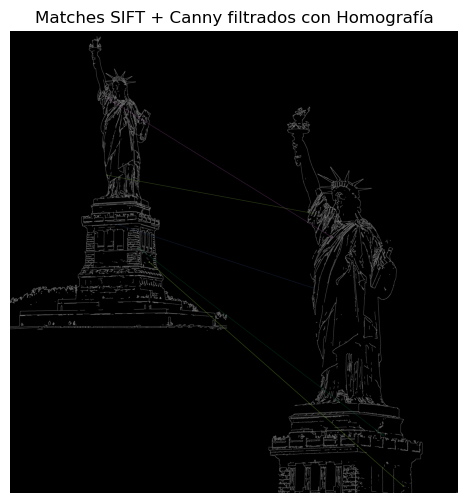

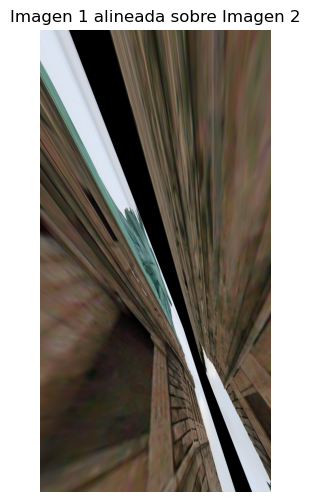

In [ ]:
import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

urls = [
    "https://upload.wikimedia.org/wikipedia/commons/a/a1/Statue_of_Liberty_7.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/1/14/Statue_of_Liberty_25.jpg"
]

def load_image_from_url(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers)
    if resp.status_code != 200:
        raise ValueError(f"Error al descargar {url}, status {resp.status_code}")
    img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"No se pudo decodificar la imagen desde {url}")
    return img

def apply_canny(img, t1=100, t2=200):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Canny(gray, t1, t2)

# Cargar imágenes
img1 = load_image_from_url(urls[0])
img2 = load_image_from_url(urls[1])

# Aplicar Canny
canny1 = apply_canny(img1)
canny2 = apply_canny(img2)

# --- SIFT ---
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(canny1, None)
kp2, des2 = sift.detectAndCompute(canny2, None)

# --- Matching ---
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

# Extraer los puntos clave de los matches
pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# Calcular homografía con RANSAC
H, mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
matches_mask = mask.ravel().tolist()

# Dibujar solo los matches considerados "inliers" por la homografía
img_matches = cv2.drawMatches(
    canny1, kp1, canny2, kp2, matches, None,
    matchesMask=matches_mask,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12,6))
plt.imshow(img_matches, cmap="gray")
plt.title("Matches SIFT + Canny filtrados con Homografía")
plt.axis("off")
plt.show()

# --- (Opcional) Warp para alinear la imagen 1 sobre la 2 ---
h2, w2 = canny2.shape
img1_aligned = cv2.warpPerspective(img1, H, (w2, h2))

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img1_aligned, cv2.COLOR_BGR2RGB))
plt.title("Imagen 1 alineada sobre Imagen 2")
plt.axis("off")
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread('img/sift_01.jpg',1)
img2 = cv2.imread('img/sift_02.jpg',1)

orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

matches = bf.match(des1, des2)
matches = sorted(matches, key = lambda x:x.distance)

img3 = cv2.drawMatches(img1,kp1,img2,kp2, matches[:30], None, flags=2)
plt.imshow(img3)
plt.show()
